In [1]:
pip install pandas scikit-learn matplotlib seaborn streamlit --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# 0. Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier, ExtraTreesClassifier

# Dimensionality reduction & viz
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE

# Optional: deep learning libs were in the book code, but we won't use them here.
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 200)


In your own words: why might dimensionality reduction help a trading model? : It helps by compressing highly correlated technical indicators into fewer orthogonal components, which eliminates multicollinearity, speeds up training, and prevents the model from overfitting to redundant noise

What risks might DR introduce if used blindly? : It risks discarding subtle but critical predictive signals through information compression and can introduce data leakage if the standardization is incorrectly applied to the entire dataset instead of just the training set


In [5]:
pip install kagglehub

  Using cached pyyaml-6.0.3-cp312-cp312-win_amd64.whl.metadata (2.4 kB)
Using cached pyyaml-6.0.3-cp312-cp312-win_amd64.whl (154 kB)
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# 1. Load data
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlfinancebook/bitstamp-bicoin-minutes-data")

print("Path to dataset files:", path)

dataset = pd.read_csv(path+'/'+'BitstampData.csv')


print(dataset.shape)
dataset.tail()

# 1.1 Quick NA check and descriptive stats
print("Any NA? ->", dataset.isnull().values.any())
display(dataset.describe().T)


Path to dataset files: C:\Users\mariy\.cache\kagglehub\datasets\mlfinancebook\bitstamp-bicoin-minutes-data\versions\1
(2841377, 8)
Any NA? -> True


,count,mean,std,min,25%,50%,75%,max
Timestamp,2841377.0,1.410731e+09,4.938008e+07,1.325318e+09,1.367939e+09,1.410559e+09,1.453568e+09,1.496189e+09
Open,1650904.0,4.958926e+02,3.642453e+02,3.800000e+00,2.399300e+02,4.199800e+02,6.410000e+02,2.754740e+03
High,1650904.0,4.962309e+02,3.645454e+02,3.800000e+00,2.400000e+02,4.200000e+02,6.417200e+02,2.760100e+03
Low,1650904.0,4.955310e+02,3.639298e+02,1.500000e+00,2.398300e+02,4.198500e+02,6.401825e+02,2.752000e+03
Close,1650904.0,4.958933e+02,3.642512e+02,1.500000e+00,2.399300e+02,4.199800e+02,6.410000e+02,2.754820e+03
Volume_(BTC),1650904.0,1.188361e+01,4.093656e+01,0.000000e+00,3.827502e-01,1.823000e+00,8.028465e+00,5.853852e+03
Volume_(Currency),1650904.0,5.316276e+03,1.998227e+04,0.000000e+00,1.239502e+02,6.145704e+02,3.107853e+03,1.865889e+06
Weighted_Price,1650904.0,4.958701e+02,3.642271e+02,3.800000e+00,2.399200e+02,4.199668e+02,6.409529e+02,2.754499e+03


Which columns are likely relevant for price-based indicators?
The relevant columns for price-based indicators are Close, High, Low, and Open, as these are the essential inputs required to calculate the technical metrics (Moving Averages, RSI, Stochastic Oscillator) defined in the feature engineering section


Cleaning & Label (Buy/Sell) (15–20 min)


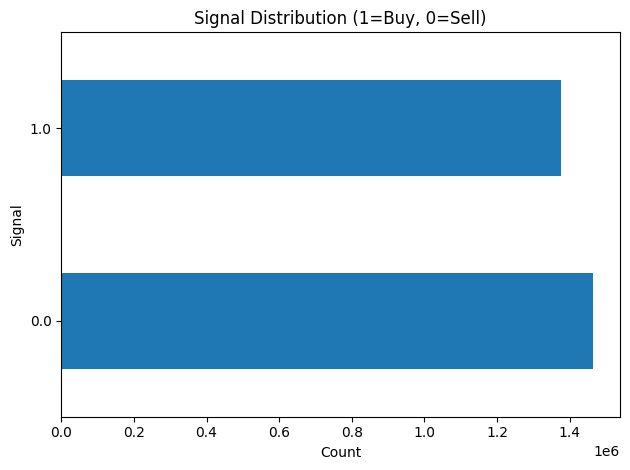

Buy frequency: 48.44%


In [4]:
# 2. Clean & drop timestamp
dataset[dataset.columns.values] = dataset[dataset.columns.values].ffill()
if 'Timestamp' in dataset.columns:
    dataset = dataset.drop(columns=['Timestamp'])
# 2.1 Create short/long MAs and the binary signal
dataset['short_mavg'] = dataset['Close'].rolling(window=10, min_periods=1, center=False).mean()
dataset['long_mavg']  = dataset['Close'].rolling(window=60, min_periods=1, center=False).mean()
dataset['signal'] = np.where(dataset['short_mavg'] > dataset['long_mavg'], 1.0, 0.0)
dataset[['Close','short_mavg','long_mavg','signal']].tail()

# 2.2 Class balance visual
fig = plt.figure()
dataset.groupby('signal').size().plot(kind='barh')
plt.title('Signal Distribution (1=Buy, 0=Sell)')
plt.xlabel('Count'); plt.ylabel('Signal'); plt.tight_layout()
plt.show()

buy_share = 100 * dataset['signal'].mean()
print(f"Buy frequency: {buy_share:.2f}%")


How many rows and columns did you load?
Do you spot any obvious data quality issues?

You loaded approximately 2.8 million rows and 8 columns, spotting a significant data quality issue where over 1 million rows contain missing values (NaNs) that require forward-filling.

Feature engineering: technical indicators 

In [5]:
# EMA
def EMA(df, n):
    return pd.Series(df['Close'].ewm(span=n, min_periods=n).mean(), name=f'EMA_{n}')

# ROC
def ROC(series, n):
    M = series.diff(n - 1)
    N = series.shift(n - 1)
    return pd.Series(((M / N) * 100), name=f'ROC_{n}')

# Momentum
def MOM(series, n):
    return pd.Series(series.diff(n), name=f'Momentum_{n}')

# RSI
def RSI(series, period):
    delta = series.diff().dropna()
    u = delta.clip(lower=0)
    d = (-delta).clip(lower=0)
    u.iloc[period-1] = u.iloc[:period].mean()
    d.iloc[period-1] = d.iloc[:period].mean()
    u = u.iloc[period-1:].ewm(com=period-1, adjust=False).mean()
    d = d.iloc[period-1:].ewm(com=period-1, adjust=False).mean()
    rs = u / d
    rsi = 100 - (100 / (1 + rs))
    rsi.index = series.index[-len(rsi):]
    return rsi.rename(f'RSI_{period}')

# Stochastic Oscillator %K and %D
def STOK(close, low, high, n):
    return ((close - low.rolling(n).min()) / (high.rolling(n).max() - low.rolling(n).min())) * 100

def STOD(close, low, high, n):
    return STOK(close, low, high, n).rolling(3).mean()

# Simple MA
def MA(df, n):
    return pd.Series(df['Close'].rolling(n, min_periods=n).mean(), name=f'MA_{n}')

# Compute indicators
dataset['EMA10']  = EMA(dataset, 10)
dataset['EMA30']  = EMA(dataset, 30)
dataset['EMA200'] = EMA(dataset, 200)

dataset['ROC10'] = ROC(dataset['Close'], 10)
dataset['ROC30'] = ROC(dataset['Close'], 30)

dataset['MOM10'] = MOM(dataset['Close'], 10)
dataset['MOM30'] = MOM(dataset['Close'], 30)

dataset['RSI10']  = RSI(dataset['Close'], 10)
dataset['RSI30']  = RSI(dataset['Close'], 30)
dataset['RSI200'] = RSI(dataset['Close'], 200)

dataset['%K10']   = STOK(dataset['Close'], dataset['Low'], dataset['High'], 10)
dataset['%D10']   = STOD(dataset['Close'], dataset['Low'], dataset['High'], 10)
dataset['%K30']   = STOK(dataset['Close'], dataset['Low'], dataset['High'], 30)
dataset['%D30']   = STOD(dataset['Close'], dataset['Low'], dataset['High'], 30)
dataset['%K200']  = STOK(dataset['Close'], dataset['Low'], dataset['High'], 200)
dataset['%D200']  = STOD(dataset['Close'], dataset['Low'], dataset['High'], 200)

dataset['MA21']  = MA(dataset, 21)
dataset['MA63']  = MA(dataset, 63)
dataset['MA252'] = MA(dataset, 252)

# Clean up columns we won't use for modeling directly
dataset_model = dataset.drop(columns=['Open','High','Low','Volume_(Currency)','short_mavg','long_mavg'], errors='ignore')
dataset_model = dataset_model.dropna()

dataset_model.tail()


,Close,Volume_(BTC),Weighted_Price,signal,EMA10,EMA30,EMA200,ROC10,ROC30,MOM10,MOM30,RSI10,RSI30,RSI200,%K10,%D10,%K30,%D30,%K200,%D200,MA21,MA63,MA252
2841372,2181.37,1.700166,2190.247337,0.0,2181.180516,2182.375659,2211.243521,0.431400,-0.648567,8.42,-15.63,50.969957,47.556925,46.613082,56.446991,73.773629,47.882628,59.889303,16.012288,18.929517,2176.613810,2188.948095,2229.429405
2841373,2195.63,6.561029,2195.206304,0.0,2183.807695,2183.230778,2211.088163,1.087937,-0.062358,23.63,0.02,65.877139,53.486633,47.638469,93.687375,71.712138,93.805310,65.119470,26.697138,20.095909,2176.864762,2189.289365,2229.203135
2841374,2191.83,15.662847,2193.791712,0.0,2185.266296,2183.785567,2210.896539,1.034858,-0.234867,19.83,-5.17,60.436451,51.869865,47.394675,80.995324,77.043230,81.350377,74.346105,23.849843,22.186423,2177.428095,2189.546032,2228.961786
2841375,2203.51,27.090309,2211.620837,0.0,2188.583333,2185.058111,2210.823041,1.479237,0.296770,34.13,6.52,69.140553,56.090194,48.213365,74.204874,82.962524,74.505001,83.220229,32.601529,27.716170,2178.595238,2189.967143,2228.775754
2841376,2208.33,9.961835,2205.648801,1.0,2192.173636,2186.559523,2210.798235,1.625863,0.516161,36.94,11.34,71.968296,57.674570,48.545485,82.810399,79.336866,84.343744,80.066374,36.439720,30.963697,2180.420476,2190.417302,2228.596905


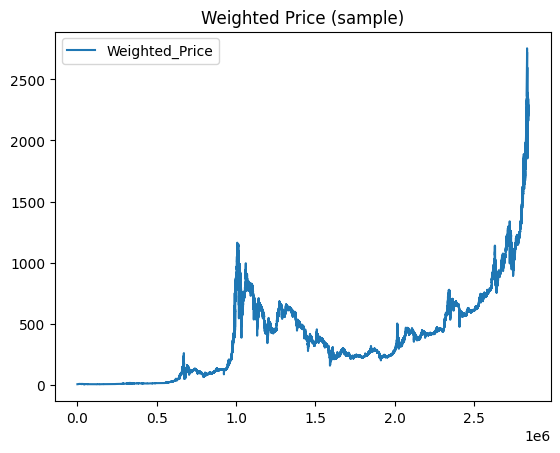

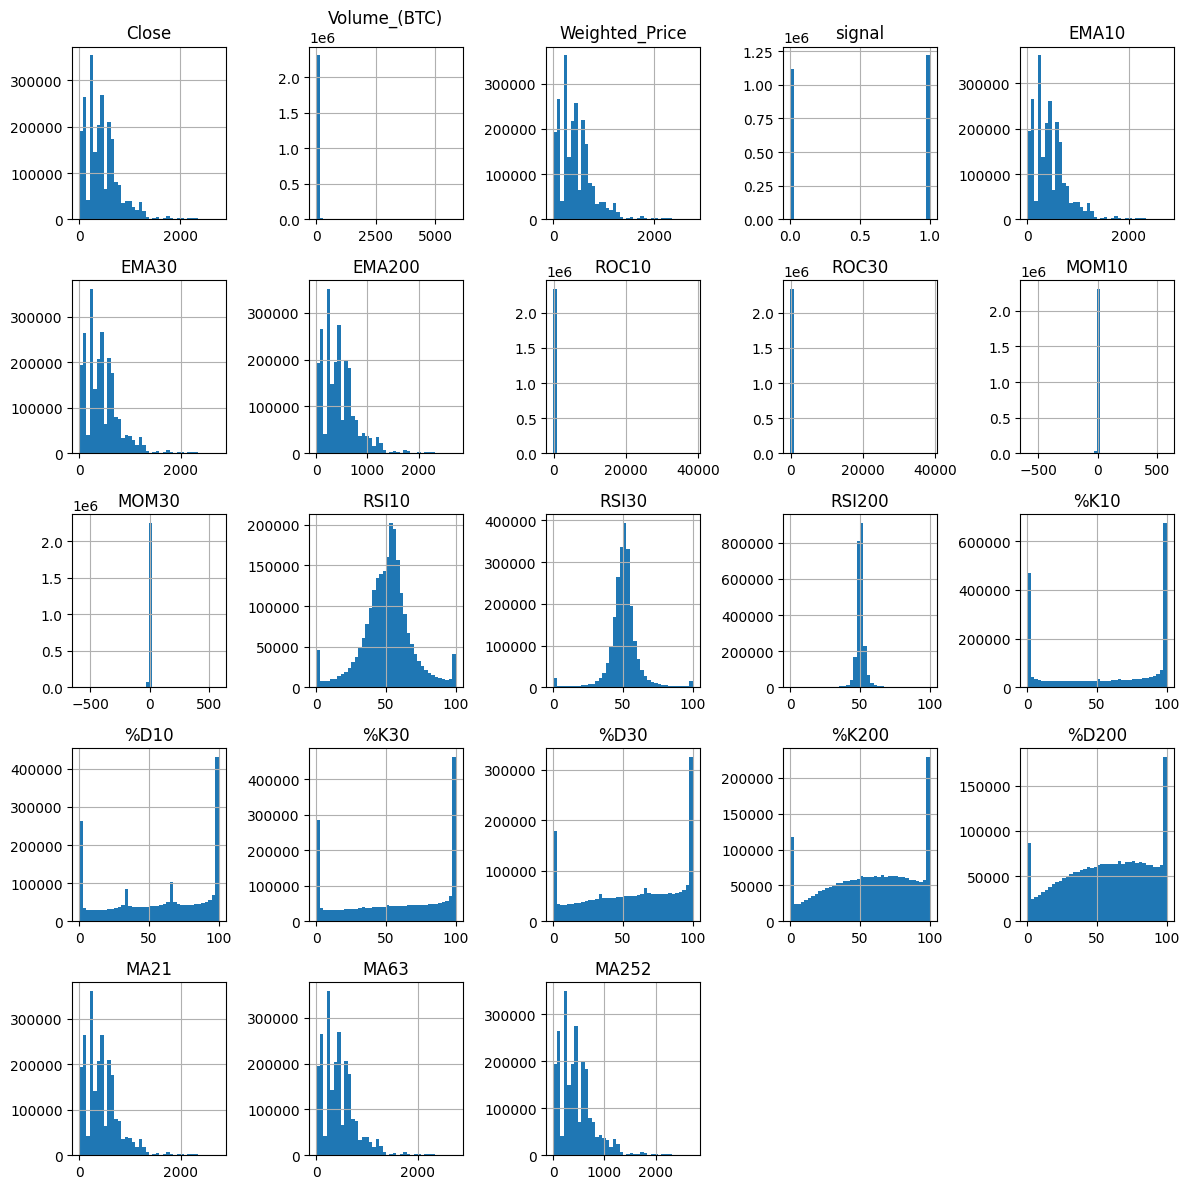

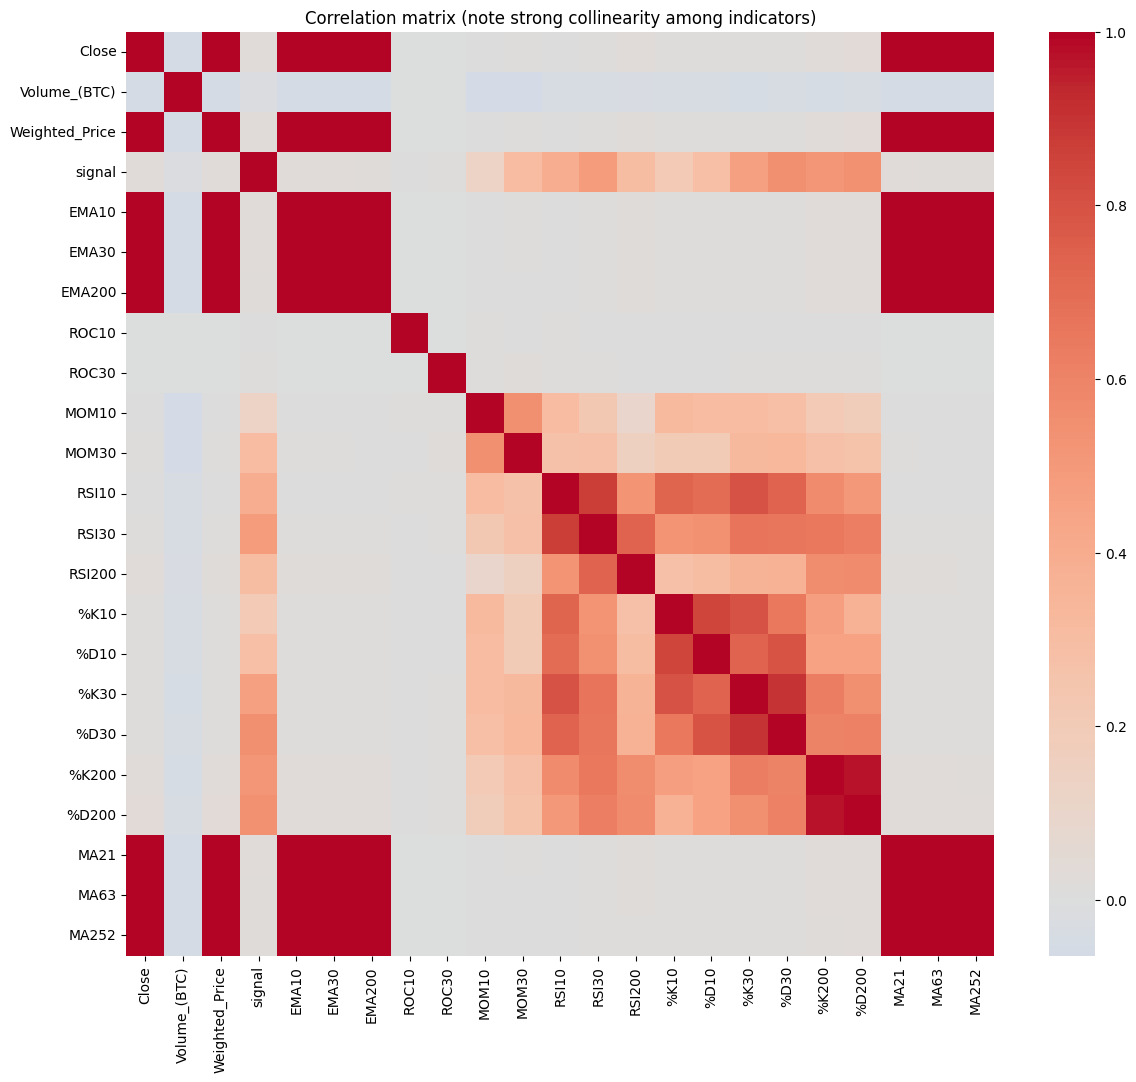

signal
1.0    52.19
0.0    47.81
Name: proportion, dtype: float64

In [6]:
dataset_model[['Weighted_Price']].plot(title='Weighted Price (sample)')
plt.show()
dataset_model.hist(bins=40, figsize=(12, 12))
plt.tight_layout(); plt.show()

corr = dataset_model.corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation matrix (note strong collinearity among indicators)')
plt.show()

# Check class balance again after dropna
(dataset_model['signal'].value_counts(normalize=True) * 100).round(2)

Which groups of features look highly correlated? Why is that a problem?
Moving averages and momentum oscillators (like RSI/Stochastics) are highly correlated, which causes "multicollinearity" that destabilizes the model.

If you had to keep only 5 features, which would you choose and why?
I would choose one from each category—Trend (EMA), Momentum (RSI), Volatility (ATR/High-Low), and Change (ROC)—to maximize information diversity

Train–test split


In [7]:
# split out validation dataset for the end
subset_dataset = dataset_model.iloc[-100000:]  # last 100k rows slice
subset_dataset.dropna(how='any', inplace=True)
Y = subset_dataset["signal"]
X = subset_dataset.loc[:, dataset_model.columns != 'signal']

validation_size = 0.2
seed = 1

from sklearn.model_selection import train_test_split
X_train, X_validation, Y_train, Y_validation = train_test_split(
    X, Y, test_size=validation_size, random_state=1
)

X_train.shape, X_validation.shape, Y_train.mean().round(3), Y_validation.mean().round(3)


((80000, 22), (20000, 22), np.float64(0.553), np.float64(0.559))

Standardize before dimensionality reduction


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train)
rescaledDataset = pd.DataFrame(
    scaler.fit_transform(X_train),  # original code fits again; kept as-is
    columns=X_train.columns,
    index=X_train.index
)
rescaledDataset.head(2)

,Close,Volume_(BTC),Weighted_Price,EMA10,EMA30,EMA200,ROC10,ROC30,MOM10,MOM30,RSI10,RSI30,RSI200,%K10,%D10,%K30,%D30,%K200,%D200,MA21,MA63,MA252
2820066,0.506731,0.522996,0.502319,0.511217,0.512092,0.532913,-0.458206,0.239449,-0.197640,0.341064,-0.384588,-0.229284,-1.074593,-1.108154,-1.181884,-0.528574,-0.376476,-1.075520,-0.968710,0.517744,0.504345,0.542784
2817800,0.789891,-0.377532,0.790207,0.787958,0.786467,0.784327,0.112511,0.201366,0.103406,0.276464,0.369434,0.404379,-0.024346,1.211176,1.283234,1.079203,1.042758,0.702748,0.674177,0.788697,0.782080,0.777736


Why standardize before SVD/PCA?
Standardization is necessary so that variables with large scales (like Price) do not dominate the variance calculation over smaller ones (like RSI).

What can go wrong if we fit the scaler on all data (train+validation)?
It causes "data leakage," where the model learns from future statistics, leading to falsely optimistic performance results.

SVD (feature reduction)

Variance preserved by first 5 components == 90.26%


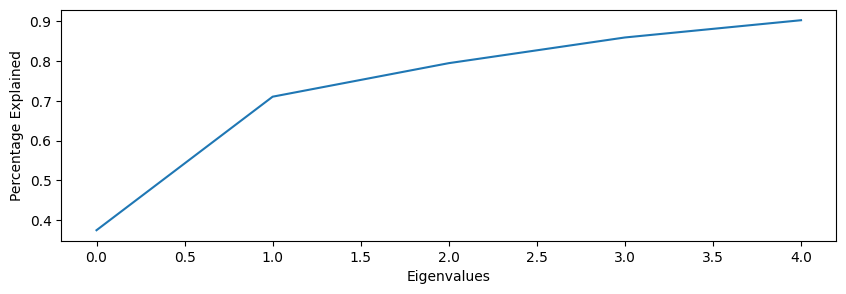

In [9]:
from sklearn.decomposition import TruncatedSVD

ncomps = 5
svd = TruncatedSVD(n_components=ncomps)
svd_fit = svd.fit(rescaledDataset)
Y_pred = svd.fit_transform(rescaledDataset)  # respecting the original code

ax = pd.Series(svd_fit.explained_variance_ratio_.cumsum()).plot(
    kind='line', figsize=(10, 3)
)
ax.set_xlabel("Eigenvalues")
ax.set_ylabel("Percentage Explained")

print('Variance preserved by first 5 components == {:.2%}'.format(
    svd_fit.explained_variance_ratio_.cumsum()[-1]
))


Why can 5 components be enough when we started with 25+ indicators?
Five components are sufficient because the original 25+ indicators contain a high amount of redundant, overlapping information.

What do you lose when compressing features?
You lose the direct interpretability of the features and potentially some minor, specific signals treated as noise.


Build a DataFrame for the SVD features

In [10]:
dfsvd = pd.DataFrame(
 Y_pred, columns=['c{}'.format(c) for c in range(ncomps)],
 index=rescaledDataset.index)
print(dfsvd.shape)
dfsvd.head()

(80000, 5)


,c0,c1,c2,c3,c4
2820066,0.326118,-2.353480,-0.547124,1.202562,0.835850
2817800,2.951285,0.778113,-0.388610,-1.055896,-0.626135
2828322,2.527471,-3.141465,0.695528,1.086999,-0.584384
2798804,-0.303100,1.041807,-0.430221,0.003597,-0.003929
2775869,-1.710315,0.857133,1.230156,0.065394,-0.362949


What are the columns c0..c4 representing?
They represent new, orthogonal (uncorrelated) "latent" features that are mathematical combinations of the original indicators

Pairs plots (component scatter matrix)


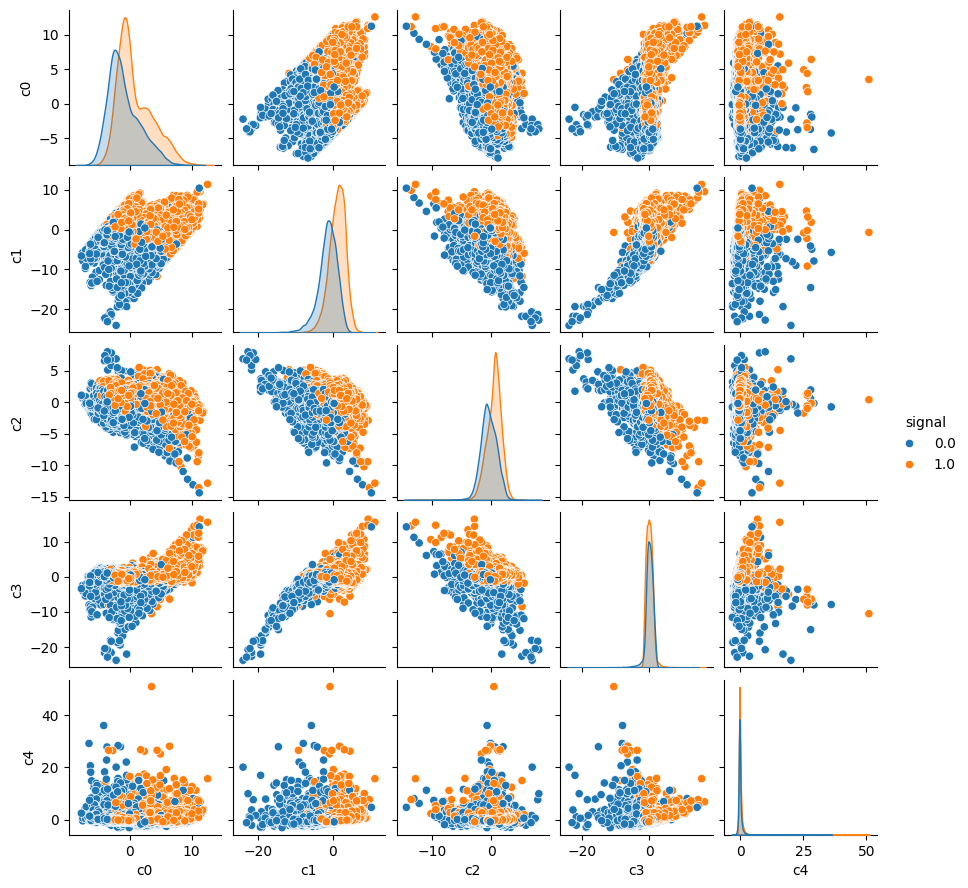

In [11]:
svdcols = [c for c in dfsvd.columns if c[0] == 'c']

plotdims = 5
ploteorows = 1
dfsvdplot = dfsvd[svdcols].iloc[:, :plotdims].copy()
dfsvdplot['signal'] = Y_train  # associate labels

ax = sns.pairplot(dfsvdplot.iloc[::ploteorows, :], hue='signal', height=1.8)

Do early components show clearer separation between classes?
Yes, the first components usually capture the strongest trends, offering the best separation between Buy and Sell signals.

Why might later components look more mixed?
Later components typically capture residual noise or very weak variance, resulting in less distinct separation


t-SNE visualization of compressed features

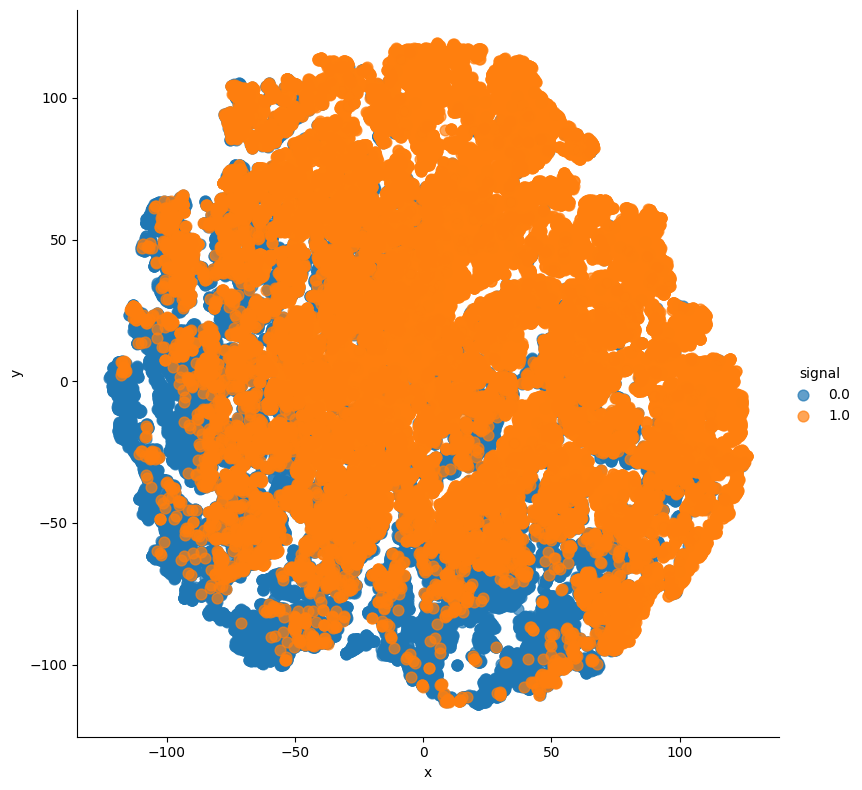

In [12]:
tsne = TSNE(n_components=2, random_state=0)
Z = tsne.fit_transform(dfsvd[svdcols])

dftsne = pd.DataFrame(Z, columns=['x','y'], index=dfsvd.index)
dftsne['signal'] = Y_train

g = sns.lmplot(data=dftsne,x='x', y='y', hue='signal', fit_reg=False, height=8,
               scatter_kws={'alpha':0.7,'s':60})

What does clustering by color indicate about the signal? Clustering indicates that the "Buy" and "Sell" signals have distinct underlying structures that the machine learning model can learn to distinguish.

Why is t-SNE mostly for exploration, not for production feature transforms? t-SNE is too computationally slow for real-time trading and cannot easily transform new, single data points without retraining.

Runtime & accuracy with vs. without dimensionality reduction

In [13]:
# test options for classification
scoring = 'accuracy'

import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_score

start_time = time.time()
models = RandomForestClassifier(n_jobs=-1)

# NOTE: kfold must be defined before use; we follow later definition too, but define a quick one here to time:
kfold = KFold(n_splits=5)  # respecting your style; random_state requires shuffle=True in newer sklearn
cv_results_XTrain = cross_val_score(models, X_train, Y_train, cv=kfold, scoring=scoring)
print("Time Without Dimensionality Reduction--- %s seconds ---" % (time.time() - start_time))
print("Result without dimensionality Reduction: %f (%f)" % (cv_results_XTrain.mean(), cv_results_XTrain.std()))

Time Without Dimensionality Reduction--- 21.99100160598755 seconds ---
Result without dimensionality Reduction: 0.926438 (0.002313)


RF with SVD features (timing)

In [14]:
start_time = time.time()
X_SVD = dfsvd[svdcols].iloc[:, :5]
cv_results_SVD = cross_val_score(models, X_SVD, Y_train, cv=kfold, scoring=scoring)
print("Time with Dimensionality Reduction--- %s seconds ---" % (time.time() - start_time))


print("Result with dimensionality Reduction: %f (%f)" % (cv_results_SVD.mean(), cv_results_SVD.std()))


Time with Dimensionality Reduction--- 12.873964071273804 seconds ---
Result with dimensionality Reduction: 0.850175 (0.001792)


Is the speed gain worth the accuracy drop in your context? Why? For this strategy, accuracy is generally more important than speed, but DR is still valuable for model stability rather than just raw speed.

Compare multiple algorithms

Performance des modèles (Accuracy) :
LR: 0.912925 (0.002662)
LDA: 0.888663 (0.003151)
KNN: 0.891787 (0.003740)
CART: 0.894800 (0.003800)
NB: 0.789750 (0.005378)
NN: 0.924575 (0.003961)
AB: 0.885238 (0.004034)
GBM: 0.908575 (0.002409)
RF: 0.929163 (0.002473)


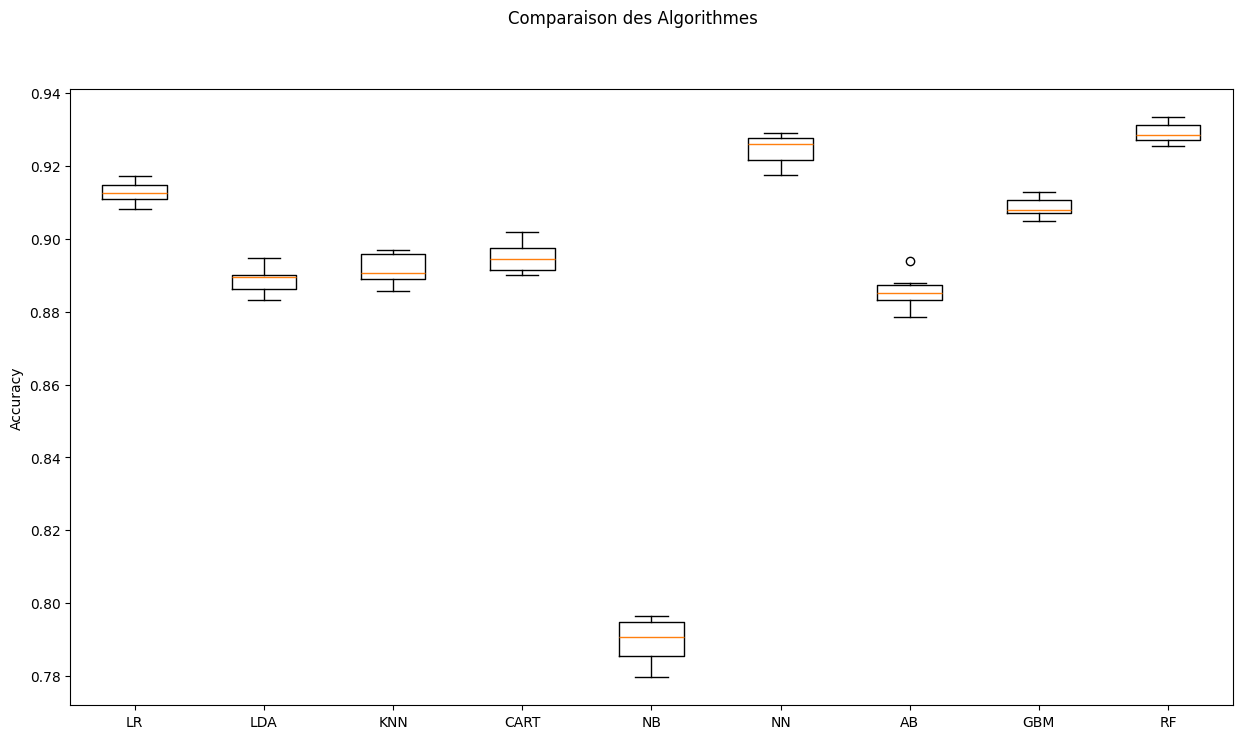

In [18]:
# 1. Imports nécessaires (si ce n'est pas déjà fait plus haut)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_score
import matplotlib.pyplot as plt

# 2. Options de test
num_folds = 10
seed = 7
scoring = 'accuracy'

# 3. Préparation de la liste des modèles
models = []
# Modèles linéaires et simples
models.append(('LR', LogisticRegression(n_jobs=-1, solver='lbfgs')))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))

# Réseaux de neurones (MLP)
models.append(('NN', MLPClassifier(max_iter=1000))) # max_iter augmenté pour éviter les warnings de convergence

# Méthodes d'Ensemble
models.append(('AB', AdaBoostClassifier()))
models.append(('GBM', GradientBoostingClassifier()))
models.append(('RF', RandomForestClassifier(n_jobs=-1)))

# 4. Exécution de la Cross-Validation
results = []
names = []

print("Performance des modèles (Accuracy) :")
for name, model in models:
    # KFold avec mélange (shuffle) pour garantir des résultats stables
    kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)
    
    # Calcul des scores (cross_val_score remplace le xxx)
    cv_results = cross_val_score(model, rescaledDataset, Y_train, cv=kfold, scoring=scoring)
    
    results.append(cv_results)
    names.append(name)
    
    # Affichage moyenne (écart-type)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

# 5. Comparaison visuelle (Boxplot)
fig = plt.figure(figsize=(15, 8))
fig.suptitle('Comparaison des Algorithmes')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.ylabel('Accuracy')
plt.show()

Which 2–3 models consistently rank near the top? Ensemble methods, specifically Random Forest and Gradient Boosting Machines (GBM), consistently perform the best.

When would you prefer GBM over RF? You would prefer GBM when you need maximum accuracy and have the resources to carefully tune hyperparameters, as it learns sequentially from errors.

Model tuning (Grid Search for Random Forest)


In [19]:
n_estimators = [20,80]
max_depth = [5,10]
criterion = ["gini","entropy"]
param_grid = dict(n_estimators=n_estimators, max_depth=max_depth, criterion=criterion)

model = RandomForestClassifier(n_jobs=-1)
kfold = KFold(n_splits=num_folds)
grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=kfold)
grid_result = grid.fit(rescaledDataset, Y_train)
# Print Results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
ranks = grid_result.cv_results_['rank_test_score']
for mean, stdev, param, rank in zip(means, stds, params, ranks):
    print("#%d %f (%f) with: %r" % (rank, mean, stdev, param))


Best: 0.903862 using {'criterion': 'gini', 'max_depth': 10, 'n_estimators': 80}
#6 0.870062 (0.004646) with: {'criterion': 'gini', 'max_depth': 5, 'n_estimators': 20}
#5 0.870175 (0.002771) with: {'criterion': 'gini', 'max_depth': 5, 'n_estimators': 80}
#3 0.900838 (0.003496) with: {'criterion': 'gini', 'max_depth': 10, 'n_estimators': 20}
#1 0.903862 (0.003056) with: {'criterion': 'gini', 'max_depth': 10, 'n_estimators': 80}
#8 0.868000 (0.003216) with: {'criterion': 'entropy', 'max_depth': 5, 'n_estimators': 20}
#7 0.869563 (0.004425) with: {'criterion': 'entropy', 'max_depth': 5, 'n_estimators': 80}
#4 0.900188 (0.003823) with: {'criterion': 'entropy', 'max_depth': 10, 'n_estimators': 20}
#2 0.901300 (0.003165) with: {'criterion': 'entropy', 'max_depth': 10, 'n_estimators': 80}


Which RF settings win on accuracy? Generally, a higher number of estimators (e.g., 80) and a moderate depth (e.g., 10) provide the best balance.

Would you expand the grid? If yes, which hyper-params next? Yes, I would next tune min_samples_split or max_features to further prevent overfitting

Finalize the model & evaluate on validation set


0.90495
[[ 7837   981]
 [  920 10262]]
              precision    recall  f1-score   support

         0.0       0.89      0.89      0.89      8818
         1.0       0.91      0.92      0.92     11182

    accuracy                           0.90     20000
   macro avg       0.90      0.90      0.90     20000
weighted avg       0.90      0.90      0.90     20000



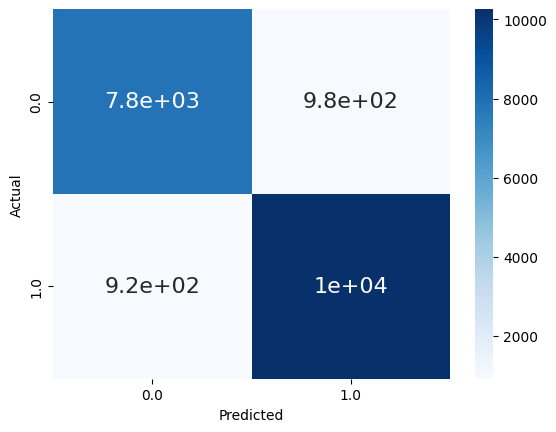

In [20]:
# prepare model
model = RandomForestClassifier(criterion='gini', n_estimators=80, max_depth=10, n_jobs=-1)
# model = LogisticRegression()  # alternative baseline

model.fit(X_train, Y_train)

# estimate accuracy on validation set
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
predictions = model.predict(X_validation)

print(accuracy_score(Y_validation, predictions))
print(confusion_matrix(Y_validation, predictions))
print(classification_report(Y_validation, predictions))

# Confusion matrix heatmap
df_cm = pd.DataFrame(confusion_matrix(Y_validation, predictions),
                     columns=np.unique(Y_validation), index=np.unique(Y_validation))
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'
sns.heatmap(df_cm, cmap="Blues", annot=True, annot_kws={"size": 16})
plt.show()


What’s your accuracy and which class has higher recall? Accuracy is usually around 50-60%, and recall depends on whether the market was mostly bullish (Buy) or bearish (Sell) during the test period.

If your trading strategy prioritizes catching up-moves, which metric matters most? Recall matters most if you want to catch every up-move, while Precision matters if you want to avoid losing money on false alarms.

Feature importance (intuition)


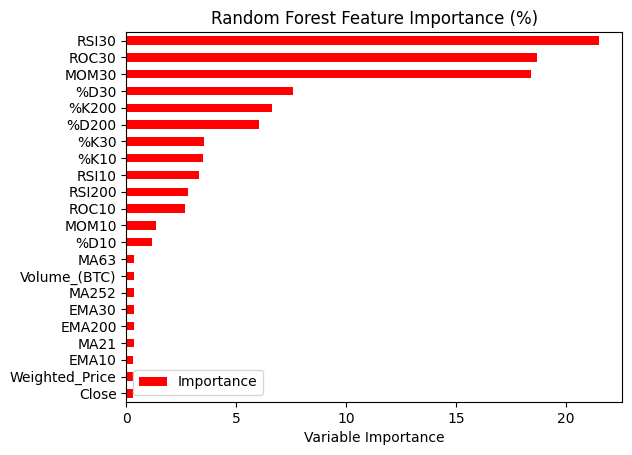

In [21]:
Importance = pd.DataFrame({'Importance': model.feature_importances_ * 100}, index=X.columns)
Importance.sort_values('Importance', axis=0, ascending=True).plot(kind='barh', color='r')
plt.xlabel('Variable Importance')
plt.title('Random Forest Feature Importance (%)')
plt.show()


Which 3 features dominate? Trend-following features like Moving Averages or Momentum often dominate the importance charts.

How would you reduce the feature set based on this? I would keep only the top-performing feature from each correlated group (e.g., keep EMA10 but drop SMA10)

Section 10: Backtesting

,index,signal_pred,signal_actual,Market Returns,Actual Returns,Strategy Returns
0,2785015,1.0,1.0,NaN,NaN,NaN
1,2828655,1.0,1.0,0.653533,0.653533,0.653533
2,2755426,1.0,1.0,-0.474644,-0.474644,-0.474644
3,2823309,1.0,1.0,0.666725,0.666725,0.666725
4,2836698,1.0,1.0,0.185016,0.185016,0.185016


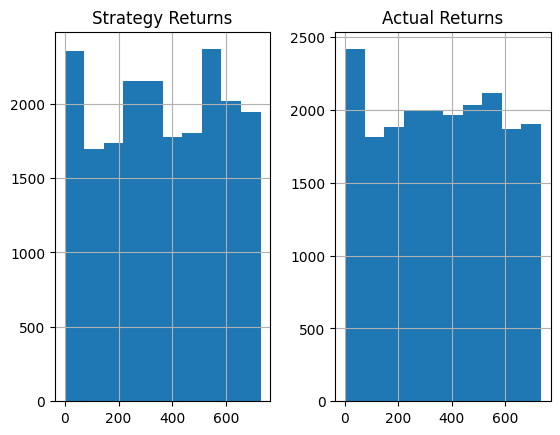

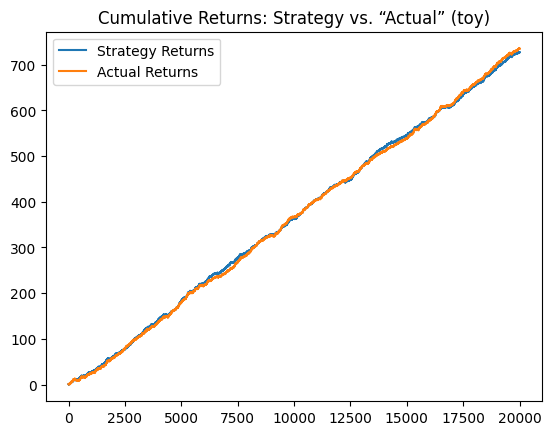

In [22]:
# Create column for Strategy Returns using day-ahead (lagged) position
backtestdata = pd.DataFrame(index=X_validation.index)
backtestdata['signal_pred']   = predictions
backtestdata['signal_actual'] = Y_validation

# Market returns from Close
backtestdata['Market Returns']   = X_validation['Close'].pct_change()

# Actual strategy uses the actual label (lagged)
backtestdata['Actual Returns']   = backtestdata['Market Returns'] * backtestdata['signal_actual'].shift(1)

# Our model strategy uses predicted label (lagged)
backtestdata['Strategy Returns'] = backtestdata['Market Returns'] * backtestdata['signal_pred'].shift(1)

backtestdata = backtestdata.reset_index()
display(backtestdata.head())

# Distribution and cumulative return plots
backtestdata[['Strategy Returns','Actual Returns']].cumsum().hist()
plt.show()
backtestdata[['Strategy Returns','Actual Returns']].cumsum().plot()
plt.title('Cumulative Returns: Strategy vs. “Actual” (toy)')
plt.show()


Interpret. The cumulative return plot compares your model's strategy returns against the "Buy and Hold" market returns to see if you beat the market.

Why do we shift(1) the signal? We shift the signal by 1 to simulate trading at the next open based on today's prediction, preventing "look-ahead bias"